In [26]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [27]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\regression\polynomial_regression\manufacturing\manufacturing.csv')
df

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.isna().sum()

Temperature (°C)                  0
Pressure (kPa)                    0
Temperature x Pressure            0
Material Fusion Metric            0
Material Transformation Metric    0
Quality Rating                    0
dtype: int64

In [30]:
df.dtypes

Temperature (°C)                  float64
Pressure (kPa)                    float64
Temperature x Pressure            float64
Material Fusion Metric            float64
Material Transformation Metric    float64
Quality Rating                    float64
dtype: object

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [32]:
df.describe()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
count,3957.000000,3957.000000,3957.000000,3957.000000,3.957000e+03,3957.000000
mean,200.034704,14.815558,2955.321308,48127.183128,1.003645e+07,96.260179
std,58.135717,5.772040,1458.224940,23812.213513,7.599356e+06,12.992262
min,100.014490,5.003008,513.706875,10156.971955,9.999462e+05,1.000000
25%,150.871296,9.692984,1798.247303,27626.929091,3.433810e+06,99.941129
50%,198.603371,14.832557,2678.277782,44611.452164,7.833390e+06,99.999997
75%,251.366552,19.749680,3929.058261,67805.443846,1.588251e+07,100.000000
max,299.992804,24.999132,7365.018714,103756.181544,2.699783e+07,100.000000


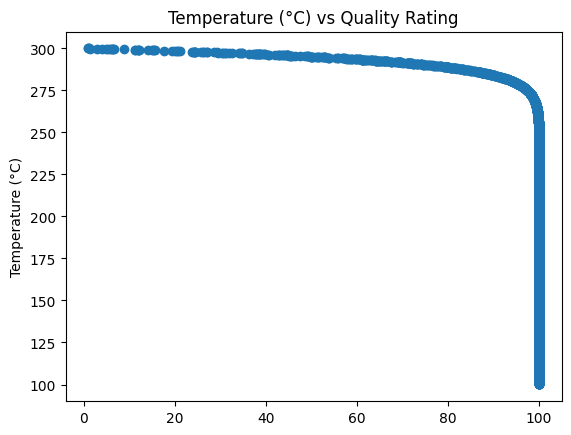

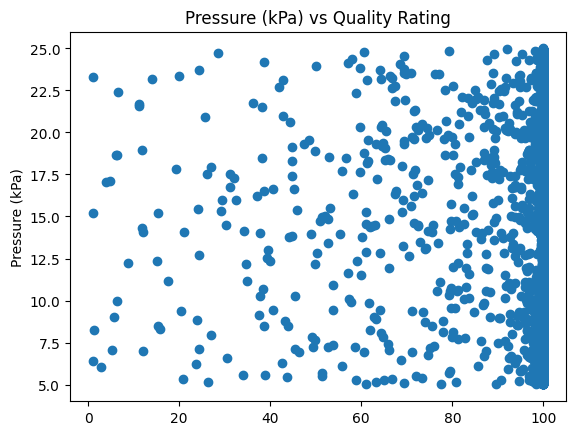

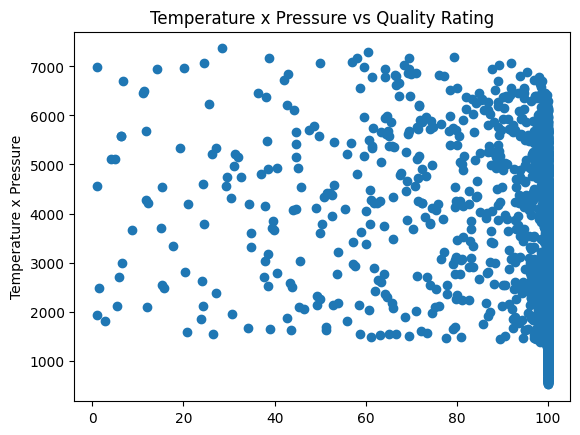

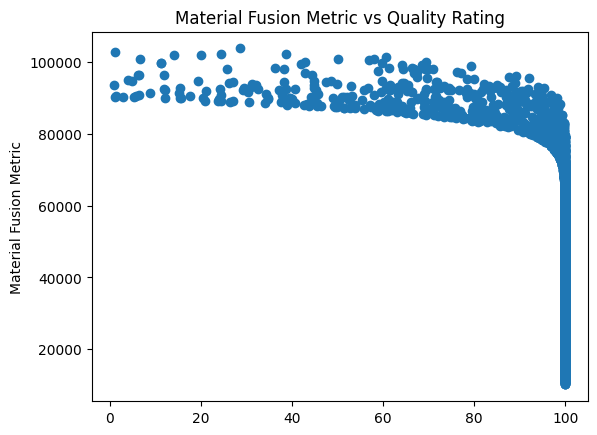

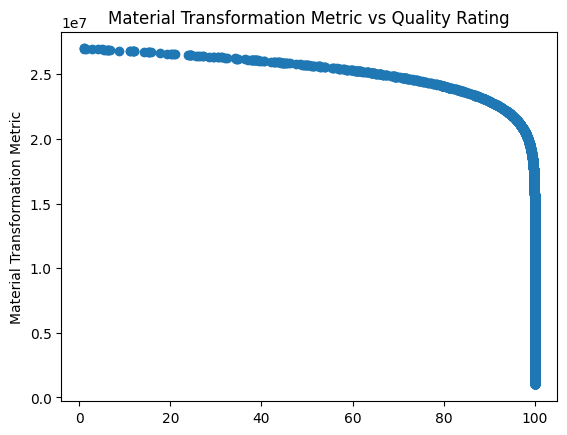

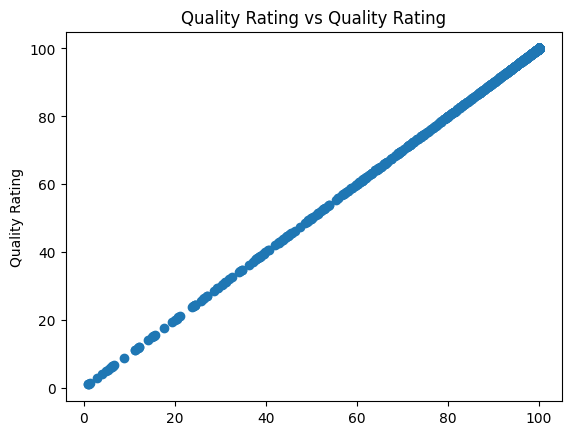

In [33]:
for i in df:
    plt.scatter(df['Quality Rating'], df[i])
    plt.title(f"{i} vs Quality Rating")
    plt.ylabel(i)
    plt.show()

In [34]:
# drop multi co-linear column as we assume all features are non co-linear
df.drop(columns='Temperature x Pressure', inplace=True)

<Axes: >

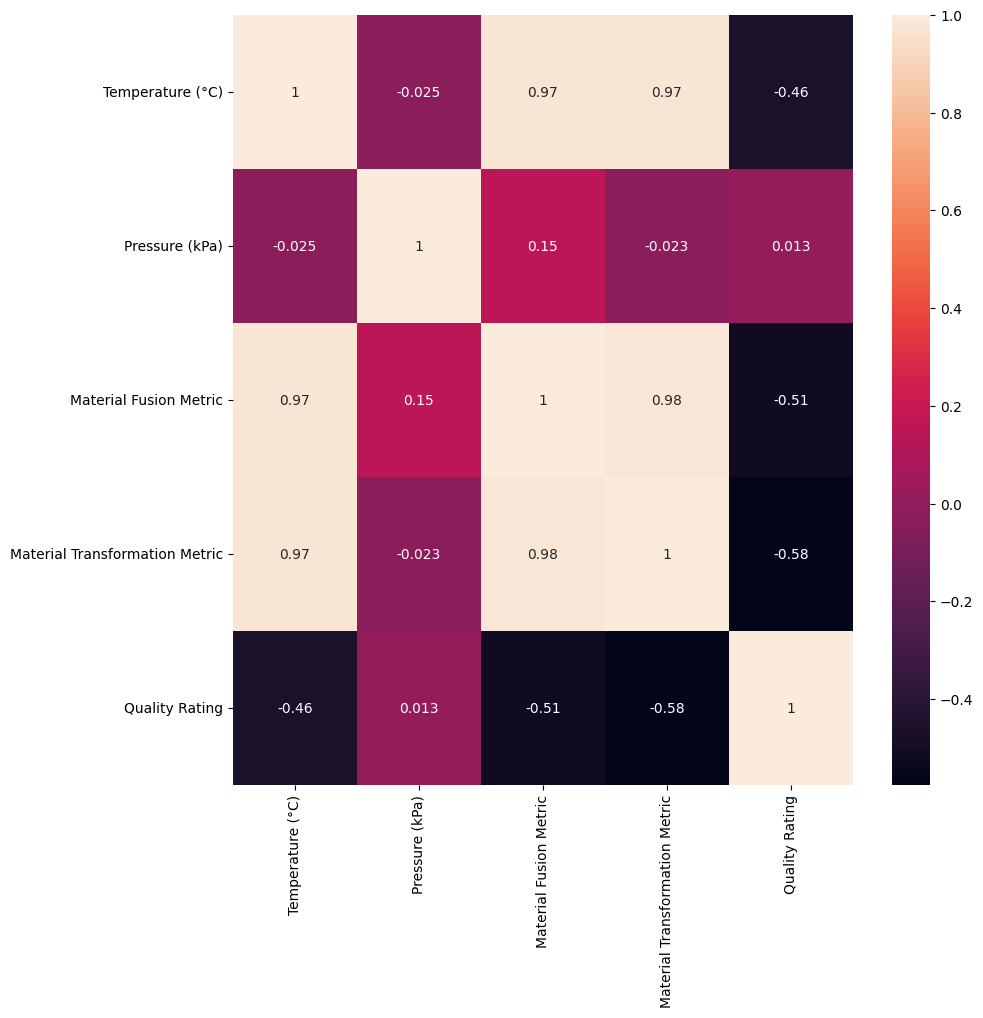

In [35]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [36]:
x=df.drop(columns='Quality Rating')
y=df['Quality Rating']

In [37]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled = minmax.fit_transform(x)

In [38]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=5)

Linear Regression

In [39]:
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()
linear_model.fit(x_train, y_train)

LinearRegression()

In [40]:
y_pred = linear_model.predict(x_test)

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print("R squared Value", r2_score(y_test, y_pred))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Value", root_mean_squared_error(y_test, y_pred))

R squared Value 0.48278808910607174
Mean Absolute Error 5.805620297431788
Root Mean Squared Value 9.61976617153315


In [42]:
from sklearn.model_selection import cross_val_score
print('LinearRegression : ', cross_val_score(LinearRegression(),x_scaled, y, cv=10).mean()*100)

LinearRegression :  49.84567615187968


Polynomial Regression

In [43]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x_scaled)

In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.3, random_state=5)

In [45]:
from sklearn.linear_model import LinearRegression
poly_model=LinearRegression()
poly_model.fit(x_train, y_train)

LinearRegression()

In [46]:
y_pred = poly_model.predict(x_test)

In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print("R squared Value", r2_score(y_test, y_pred))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Value", root_mean_squared_error(y_test, y_pred))

R squared Value 0.923778047633391
Mean Absolute Error 2.4272655740585765
Root Mean Squared Value 3.6929233301222157


In [48]:
from sklearn.model_selection import cross_val_score
print('Polinomial Regression : ', cross_val_score(LinearRegression(),x_poly, y, cv=10).mean()*100)

Polinomial Regression :  92.3057001950232


In [49]:
dict1 = {"model":poly_model, 'scaler': minmax, 'degree': poly}
dict1

{'model': LinearRegression(),
 'scaler': MinMaxScaler(),
 'degree': PolynomialFeatures()}

In [50]:
import pickle
with open("manufacturing_model.pkl", 'wb') as obj1:
    pickle.dump(dict1, obj1)